# Alpha-form screen: restrained superposition-$g$ latent FTNODE (partial Duffing obs)

A slim, fast **pilot** that screens the three coefficient parameterizations for the
superposition-$g$ equilibrium map (see §2.1) on the **L-FT model alone** — the three
'models' compared are the $\alpha$-forms **sparsemax / softmax / sigmoid_l1**, each over
**5 seeds** (15 runs) on a fixed dataset. There is no L-N or L-FT+res and no residual
regularizer here. Use §5 (accuracy, anchor sparsity, structure, recoverability) to pick
the form for the full L-N / L-FT / L-FT+res comparison notebook.

In [1]:
import sys, pathlib, time
ROOT = pathlib.Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as Fnn


In [2]:
# ---- alpha-form screen configuration --------------------------------------------
# SMOKE=True gives a fast end-to-end check (tiny data / few epochs / 2 seeds).
SMOKE = False

ELL       = 8       # number of learnable anchor vectors g_i (over-specified vs m=4)
LAM_ALPHA = 1e-3    # alpha-sparsity weight: entropy(softmax) / L1(sigmoid_l1); sparsemax uses 0
M_LAT     = 4

N_EPOCHS = 3 if SMOKE else 200
SEEDS    = list(range(2)) if SMOKE else list(range(5))

# The three "models" compared are the three coefficient forms, all on the superposition-g L-FT.
FORM_CFG = [
    {'name': 'sparsemax',  'lam_alpha': 0.0,       'color': 'C0'},
    {'name': 'softmax',    'lam_alpha': LAM_ALPHA, 'color': 'C1'},
    {'name': 'sigmoid_l1', 'lam_alpha': LAM_ALPHA, 'color': 'C2'},
]
MODEL_NAMES = [c['name'] for c in FORM_CFG]
MODEL_COLOR = {c['name']: c['color'] for c in FORM_CFG}
print(f'{len(FORM_CFG)} alpha-forms x {len(SEEDS)} seeds = {len(FORM_CFG) * len(SEEDS)} runs, '
      f'{N_EPOCHS} epochs each (ELL={ELL}, LAM_ALPHA={LAM_ALPHA})')


3 alpha-forms x 5 seeds = 15 runs, 200 epochs each (ELL=8, LAM_ALPHA=0.001)


## 1. Duffing plant & partial-observation data

Long rollouts of the Duffing plant under random constant $u$; training sees only $y=q$
(the velocity $\dot q$ is hidden). One fixed dataset is reused for every form and seed, so
variation comes only from model init and minibatch order.

In [3]:
from __future__ import annotations

from dataclasses import dataclass

import numpy as np


@dataclass(frozen=True)
class DuffingParams:
    delta: float = 0.2  # damping; small enough that approach is underdamped


def F(x: np.ndarray, u: float | np.ndarray, params: DuffingParams) -> np.ndarray:
    """Plant vector field. x has shape (..., 2); u is scalar (or shape (...,))."""
    x1 = x[..., 0]
    x2 = x[..., 1]
    f1 = x2
    f2 = -params.delta * x2 - x1**3 + x1 + np.asarray(u)
    return np.stack([f1, f2], axis=-1)


def DxF(x: np.ndarray, u: float, params: DuffingParams) -> np.ndarray:
    """Jacobian D_x F at a single state x of shape (2,)."""
    x1 = x[..., 0]
    return np.array(
        [
            [0.0, 1.0],
            [1.0 - 3.0 * x1**2, -params.delta],
        ]
    )


def DuF(x: np.ndarray, u: float, params: DuffingParams) -> np.ndarray:
    """Jacobian D_u F at state x. Returns shape (2,)."""
    return np.array([0.0, 1.0])


def equilibria(u: float) -> list[np.ndarray]:
    """Equilibria of the autonomous Duffing system at fixed u.

    Solve x1**3 - x1 - u = 0 (with x2 = 0). Returns the real roots as
    states (x1, 0). For |u| < 2/(3*sqrt(3)) ~= 0.385 there are three roots:
    two sinks (outer roots) and one saddle (middle root). Sink labelled by
    sign of x1.
    """
    coeffs = [1.0, 0.0, -1.0, -float(u)]
    roots = np.roots(coeffs)
    real_roots = sorted(r.real for r in roots if abs(r.imag) < 1e-9)
    return [np.array([r, 0.0]) for r in real_roots]


def sinks(u: float) -> dict[str, np.ndarray]:
    """Return the two hyperbolic sinks (left/right) when bistable.

    Falls back to a single sink when u is outside the bistable window.
    """
    eqs = equilibria(u)
    if len(eqs) == 3:
        return {"left": eqs[0], "right": eqs[2]}
    return {"only": eqs[0]}


def simulate(
    x0: np.ndarray,
    u_of_t,
    params: DuffingParams,
    t_grid: np.ndarray,
) -> np.ndarray:
    """Integrate the plant on t_grid with control u_of_t (callable t -> u).

    Uses RK4 with the t_grid spacing. Returns array of shape (T, 2).
    """
    xs = np.empty((len(t_grid), 2))
    xs[0] = x0
    for i in range(len(t_grid) - 1):
        t = t_grid[i]
        h = t_grid[i + 1] - t
        x = xs[i]
        u1 = u_of_t(t)
        u2 = u_of_t(t + 0.5 * h)
        u4 = u_of_t(t + h)
        k1 = F(x, u1, params)
        k2 = F(x + 0.5 * h * k1, u2, params)
        k3 = F(x + 0.5 * h * k2, u2, params)
        k4 = F(x + h * k3, u4, params)
        xs[i + 1] = x + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)
    return xs

In [4]:
torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

params = DuffingParams(delta=0.2)
print('open-loop sinks at u=0:', sinks(0.0))

device: cpu
open-loop sinks at u=0: {'left': array([-1.,  0.]), 'right': array([1., 0.])}


train: window torch.Size([512, 8]) u torch.Size([512]) y_long torch.Size([512, 201])
val  : window torch.Size([64, 8]) u torch.Size([64]) y_long torch.Size([64, 601]) (extrapolation horizon)


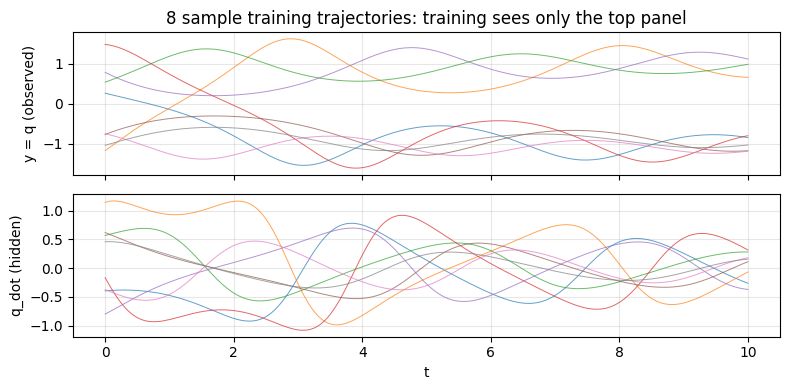

In [5]:
h_dt   = 0.05      # integration timestep
tau    = 8         # encoder window length
L      = 200       # training rollout length (T = 10)
L_eval = 600       # eval horizon (T = 30) -> tests extrapolation
u_range = 0.25
x_range = 1.6

if SMOKE:
    L, L_eval = 20, 30
    N_TRAJ_TR, N_TRAJ_VA = 32, 16
else:
    N_TRAJ_TR, N_TRAJ_VA = 512, 64

def make_dataset(n_traj=512, L=L, tau=tau, h=h_dt, seed=0):
    rng = np.random.default_rng(seed)
    # Total trajectory length: tau (warmup) + L (rollout target) + 1
    Ttot = tau + L + 1
    t_grid = np.arange(Ttot) * h
    Xfull = np.zeros((n_traj, Ttot, 2), dtype=np.float32)
    U     = np.zeros((n_traj,), dtype=np.float32)
    for i in range(n_traj):
        # Random IC anywhere reasonable (both basins, with some velocity).
        x0 = np.array([
            rng.uniform(-x_range, x_range),
            rng.uniform(-1.0, 1.0),
        ], dtype=np.float64)
        u  = float(rng.uniform(-u_range, u_range))
        traj = simulate(x0, lambda t, _u=u: _u, params, t_grid)
        Xfull[i] = traj.astype(np.float32)
        U[i] = u
    Y    = Xfull[..., 0]                 # observed: q only
    Wind = Y[:, :tau]                    # encoder window
    Yl   = Y[:, tau:tau + L + 1]         # rollout target (L+1 samples)
    Xl   = Xfull[:, tau:tau + L + 1]     # full state for evaluation
    return (
        torch.from_numpy(Wind),
        torch.from_numpy(U),
        torch.from_numpy(Yl),
        torch.from_numpy(Xl),
    )

Wtr, Utr, Ytr, Xtr = make_dataset(n_traj=N_TRAJ_TR, L=L, seed=0)
Wva, Uva, Yva, Xva = make_dataset(n_traj=N_TRAJ_VA, L=L_eval, seed=1)
print('train: window', Wtr.shape, 'u', Utr.shape, 'y_long', Ytr.shape)
print('val  : window', Wva.shape, 'u', Uva.shape, 'y_long', Yva.shape, '(extrapolation horizon)')

fig, axes = plt.subplots(2, 1, figsize=(8, 4), sharex=True)
tline = np.arange(L + 1) * h_dt
for i in range(8):
    axes[0].plot(tline, Ytr[i].numpy(), lw=0.7, alpha=0.7)
    axes[1].plot(tline, Xtr[i, :, 1].numpy(), lw=0.7, alpha=0.7)
axes[0].set_ylabel('y = q (observed)'); axes[0].grid(alpha=0.3)
axes[1].set_ylabel('q_dot (hidden)'); axes[1].set_xlabel('t'); axes[1].grid(alpha=0.3)
axes[0].set_title('8 sample training trajectories: training sees only the top panel')
plt.tight_layout(); plt.show()

## 2. Superposition-$g$ L-FT model

Shared bounded encoder $\phi(\text{window})\to z_0$ and linear decoder $\psi(z)=c^\top z$,
latent dim $m=4$. The latent field is $F=A(z)\,(z-g(z,u))$ with
$A(z)=-(LL^\top+\sigma_{\min}I)+(M-M^\top)$ fixed; only the equilibrium map $g$ is the
restrained superposition defined next.

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=64, depth=3, last_zero=False):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)
        if last_zero:
            with torch.no_grad():
                self.net[-1].weight.zero_(); self.net[-1].bias.zero_()
    def forward(self, z): return self.net(z)


class Encoder(nn.Module):
    """Bounded encoder: phi(window) = z_scale * tanh(MLP(window)), so z0 in [-z_scale, z_scale]^m."""
    def __init__(self, tau, m, hidden=64, depth=2, z_scale=2.0):
        super().__init__()
        self.net = MLP(tau, m, hidden=hidden, depth=depth)
        self.z_scale = z_scale
    def forward(self, window):
        return self.z_scale * torch.tanh(self.net(window))


class LinearDecoder(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.c = nn.Linear(m, 1, bias=True)
    def forward(self, z):
        return self.c(z).squeeze(-1)


class LatentSysID(nn.Module):
    def __init__(self, encoder, dynamics, decoder):
        super().__init__()
        self.encoder  = encoder
        self.dynamics = dynamics
        self.decoder  = decoder
    def encode(self, w): return self.encoder(w)
    def decode(self, z): return self.decoder(z)
    def F(self, z, u):   return self.dynamics.F(z, u)


def rk4_step(F_fn, z, u, h):
    k1 = F_fn(z, u)
    k2 = F_fn(z + 0.5 * h * k1, u)
    k3 = F_fn(z + 0.5 * h * k2, u)
    k4 = F_fn(z + h * k3, u)
    return z + (h / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def rollout_y(model, window, u, L, h):
    """Encode window -> z0; integrate L steps; decode each z to y. Returns (yhat, zs)."""
    z = model.encode(window)
    ys = [model.decode(z)]; zs = [z]
    for _ in range(L):
        z = rk4_step(model.F, z, u, h)
        zs.append(z); ys.append(model.decode(z))
    return torch.stack(ys, dim=1), torch.stack(zs, dim=1)


# Box radii consistent with the data envelope (observed q ~ [-1.7, 1.7]) => R_z = R_g = 2.0.
R_LATENT = 2.0


### 2.1 Superposition-g and its three coefficient forms

The baseline equilibrium map $g(z,u)=R_g\tanh(\mathrm{MLP}([z,u]))$ is a full MLP and can
absorb most of the modelling load. We replace it with a **restrained superposition of
learnable anchor vectors**

$$ g_\theta(z,u) = \sum_{i=1}^{\ell} \alpha_i(z,u)\, g_i, \qquad g_i\in\mathbb{R}^m, $$

with $\ell=8$ over-specified vs $m=4$. **The coefficient map $a(z,u)\!\to\!\mathbb{R}^\ell$ is a
single affine readout (no hidden layers)** so it cannot overpower $g$; all expressiveness now
lives in the $\alpha$-form squashing and the small anchor basis, forcing structure into $A$.
The intent is that redundant $\alpha_i\to 0$, exposing the effective latent dimension.

The $\ell$ anchors are the **rows of a single learnable parameter matrix
$V\in\mathbb{R}^{\ell\times m}$** (small init; `self.V` in `SuperpositionG`): row $V_i$ is the
$i$-th anchor vector — i.e. the $g_i$ above. How $V$ becomes the anchors and how the raw logits
$a=a(z,u)$ are squashed into $\alpha$ is the only thing that differs between the three forms:

- `sparsemax` — $\alpha=\mathrm{sparsemax}(a)$ is convex ($\sum_i\alpha_i=1,\ \alpha_i\ge 0$, many
  **exactly** $0$); bounded anchors $g_i=R_g\tanh(V_i)$; $g=\sum_i\alpha_i g_i$ is a convex
  combination ⇒ $\|g\|_\infty\le R_g$.
- `softmax` — same convex / bounded-anchor construction with $\alpha=\mathrm{softmax}(a)$; sparsity
  only *soft* (no exact zeros).
- `sigmoid_l1` — independent gates $\alpha_i=\sigma(a_i)\in[0,1]$; **raw** anchors $g_i=V_i$;
  boundedness enforced by an outer squash on the whole sum,
  $g=R_g\tanh\!\big(\sum_i\sigma(a_i)\,V_i\big)$ (gates don't sum to 1, so a per-anchor bound
  would not cap the sum).

$A(z)=-(LL^\top+\sigma_{\min}I)+(M-M^\top)$ is **unchanged**.


In [7]:
def sparsemax(z, dim=-1):
    """Sparsemax (Martins & Astudillo, 2016). Projects logits onto the probability simplex;
    yields exact zeros. Operates on `dim` by flattening leading dims."""
    z = z.transpose(dim, -1)
    shp = z.shape
    z2 = z.reshape(-1, shp[-1])
    zs, _ = torch.sort(z2, descending=True, dim=-1)
    rng = torch.arange(1, z2.shape[-1] + 1, device=z2.device, dtype=z2.dtype)
    cssv = zs.cumsum(-1)
    support = (1.0 + rng * zs) > cssv
    k = support.sum(-1, keepdim=True).clamp_min(1)
    tau = (cssv.gather(-1, k - 1) - 1.0) / k
    return torch.clamp(z2 - tau, min=0.0).reshape(shp).transpose(dim, -1)


class SuperpositionG(nn.Module):
    """Restrained equilibrium map g(z,u) = sum_i alpha_i(z,u) * g_i.

    The coefficient map is a *single affine readout* (NO hidden layers) so it cannot overpower g.
    The ell anchors are the rows of a learnable matrix V (row V_i is the anchor g_i).
    alpha_form in {sparsemax, softmax, sigmoid_l1}. Interface g(z,u)->[...,m] matches the
    baseline and works on 2-D and 3-D (rollout) inputs.
    """
    def __init__(self, m, q, ell, R_g=2.0, alpha_form='sparsemax'):
        super().__init__()
        assert alpha_form in ('sparsemax', 'softmax', 'sigmoid_l1')
        self.m = m; self.q = q; self.ell = ell
        self.R_g = R_g; self.alpha_form = alpha_form
        self.alpha_lin = nn.Linear(m + q, ell)            # single affine layer (weak by design)
        self.V = nn.Parameter(0.1 * torch.randn(ell, m))  # anchor matrix; rows V_i are the g_i

    def _prep(self, z, u):
        if u.dim() == z.dim() - 1:
            u = u.unsqueeze(-1)
        return torch.cat([z, u], dim=-1)

    def coeffs(self, z, u):
        a = self.alpha_lin(self._prep(z, u))              # [..., ell]
        if self.alpha_form == 'softmax':
            return torch.softmax(a, dim=-1)
        if self.alpha_form == 'sparsemax':
            return sparsemax(a, dim=-1)
        return torch.sigmoid(a)                            # sigmoid_l1: independent gates

    def anchors(self):
        # convex forms use bounded anchors; sigmoid_l1 uses raw V (outer tanh bounds g)
        return self.V if self.alpha_form == 'sigmoid_l1' else self.R_g * torch.tanh(self.V)

    def forward(self, z, u):
        alpha = self.coeffs(z, u)                          # [..., ell]
        s = torch.einsum('...l,lm->...m', alpha, self.anchors())
        if self.alpha_form == 'sigmoid_l1':
            return self.R_g * torch.tanh(s)
        return s                                           # convex combo already in [-R_g, R_g]


class LatentFTNODESuper(nn.Module):
    """LatentFTNODE with A unchanged (sym-neg-def + skew) and g replaced by SuperpositionG."""
    def __init__(self, m=4, q=1, hidden=64, depth=3, sigma_min=0.1, R_g=2.0,
                 ell=8, alpha_form='sparsemax'):
        super().__init__()
        self.m = m; self.q = q
        self.sigma_min = sigma_min
        self.R_g = R_g
        self.ell = ell; self.alpha_form = alpha_form
        tril = torch.tril_indices(m, m)
        self.register_buffer('_tril_row', tril[0])
        self.register_buffer('_tril_col', tril[1])
        self._n_tril = m * (m + 1) // 2
        diag_mask = (tril[0] == tril[1]).float()
        self.register_buffer('_diag_mask', diag_mask)
        self.L_net = MLP(m, self._n_tril, hidden=hidden, depth=depth)
        self.S_net = MLP(m, m * m, hidden=hidden, depth=depth, last_zero=True)
        self.g_mod = SuperpositionG(m, q, ell, R_g=R_g, alpha_form=alpha_form)

    def _L(self, z):
        B = z.shape[0]
        raw = self.L_net(z)
        diag_sp = Fnn.softplus(raw) * self._diag_mask
        offdiag = raw * (1.0 - self._diag_mask)
        flat = diag_sp + offdiag
        L = z.new_zeros(B, self.m, self.m)
        L[:, self._tril_row, self._tril_col] = flat
        return L

    def _S(self, z):
        B = z.shape[0]
        M = self.S_net(z).view(B, self.m, self.m)
        return M - M.transpose(1, 2)

    def A(self, z):
        L = self._L(z)
        I = torch.eye(self.m, device=z.device, dtype=z.dtype)
        return -(L @ L.transpose(1, 2) + self.sigma_min * I) + self._S(z)

    def g(self, z, u):
        return self.g_mod(z, u)

    def coeffs(self, z, u):
        return self.g_mod.coeffs(z, u)

    def F(self, z, u):
        diff = z - self.g(z, u)
        return torch.einsum('bij,bj->bi', self.A(z), diff)


def build_lft(alpha_form, m=4, sigma_min=0.1, R_g=R_LATENT, R_z=R_LATENT, ell=None):
    """Restrained superposition-g L-FT with an explicit coefficient form."""
    ell = ELL if ell is None else ell
    enc = Encoder(tau, m, hidden=64, depth=2, z_scale=R_z)
    dyn = LatentFTNODESuper(m=m, q=1, hidden=64, depth=3, sigma_min=sigma_min,
                            R_g=R_g, ell=ell, alpha_form=alpha_form)
    dec = LinearDecoder(m)
    return LatentSysID(enc, dyn, dec)

_probe = build_lft('sparsemax')
print(f'superposition-g L-FT: ell={ELL}  params={sum(p.numel() for p in _probe.parameters())}')


superposition-g L-FT: ell=8  params=24051


## 3. Trainer

Rollout-MSE on $y$ over $L{+}1$ steps plus the $\alpha$-sparsity penalty (entropy for
`softmax`, $L_1$ of the gates for `sigmoid_l1`, none for `sparsemax`). Best-validation
weights are checkpointed and restored before evaluation.

In [8]:
Wtr_d, Utr_d, Ytr_d = Wtr.to(device), Utr.to(device), Ytr.to(device)
Wva_d, Uva_d, Yva_d = Wva.to(device), Uva.to(device), Yva.to(device)

def train_one(model, n_epochs=120, lr=3e-3, batch=64, clip=1.0, label='model',
              ckpt_path=None, lam_alpha=0.0, verbose=True):
    """Rollout-MSE on y + lam_alpha * alpha-sparsity (L1-mean gates for 'sigmoid_l1', entropy
    for 'softmax', none for 'sparsemax'). Checkpoints best-validation weights.
    No residual penalty here — this notebook only screens the coefficient form."""
    model = model.to(device)
    if ckpt_path is None:
        ckpt_path = f'best_model-duffing-{label}.pth'
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    history = {'train': [], 'val_extrap': [], 'zmax': [], 'alpha': [],
               'diverged_at': None, 'best_val': float('inf'), 'best_epoch': None,
               'ckpt_path': ckpt_path}
    diverged = False
    t0 = time.time()
    for epoch in range(n_epochs):
        model.train()
        perm = torch.randperm(Wtr_d.shape[0], device=device)
        ep_losses = []; ep_alpha = []
        ep_zmax = 0.0
        for i in range(0, len(perm), batch):
            idx = perm[i:i+batch]
            w = Wtr_d[idx]; u = Utr_d[idx]; y = Ytr_d[idx]
            yhat, zs = rollout_y(model, w, u, L, h_dt)
            loss = ((yhat - y) ** 2).mean()
            alpha_pen = zs.new_zeros(())
            if lam_alpha > 0.0 and hasattr(model.dynamics, 'coeffs'):
                u_steps = u.unsqueeze(1).expand(zs.shape[0], zs.shape[1])
                alpha = model.dynamics.coeffs(zs, u_steps)                  # (B, L+1, ell)
                af = getattr(model.dynamics, 'alpha_form', 'sigmoid_l1')
                if af == 'softmax':
                    alpha_pen = -(alpha.clamp_min(1e-9).log() * alpha).sum(-1).mean()
                elif af == 'sigmoid_l1':
                    alpha_pen = alpha.mean()
                loss = loss + lam_alpha * alpha_pen
            if not torch.isfinite(loss):
                diverged = True; history['diverged_at'] = epoch; break
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            ep_losses.append(loss.item()); ep_alpha.append(alpha_pen.item())
            with torch.no_grad():
                ep_zmax = max(ep_zmax, zs.norm(dim=-1).max().item())
        if diverged:
            if verbose: print(f'[{label}] diverged at epoch {epoch}')
            break
        sched.step()
        model.eval()
        with torch.no_grad():
            yhat_v, _ = rollout_y(model, Wva_d, Uva_d, L_eval, h_dt)
            val = ((yhat_v - Yva_d) ** 2).mean().item()
        history['train'].append(float(np.mean(ep_losses)))
        history['val_extrap'].append(val)
        history['zmax'].append(ep_zmax)
        history['alpha'].append(float(np.mean(ep_alpha)) if ep_alpha else 0.0)
        if np.isfinite(val) and val < history['best_val']:
            history['best_val'] = val; history['best_epoch'] = epoch
            torch.save(model.state_dict(), ckpt_path)
        if verbose and (epoch % 10 == 0 or epoch == n_epochs - 1):
            print(f'[{label}] ep {epoch:3d}  train {history["train"][-1]:.3e}  '
                  f'val(L={L_eval}) {val:.3e}  alpha {history["alpha"][-1]:.3e}  '
                  f'zmax {ep_zmax:.2f}  ({time.time()-t0:.1f}s)')
    if verbose and history['best_epoch'] is not None:
        print(f'[{label}] best val {history["best_val"]:.3e} @ epoch {history["best_epoch"]}')
    return model, history


def restore_best(model, hist, label, verbose=True):
    cp = hist.get('ckpt_path')
    if hist.get('best_epoch') is None or cp is None or not pathlib.Path(cp).exists():
        if verbose:
            print(f'[{label}] no checkpoint to restore - keeping final-epoch weights')
        return model
    model.load_state_dict(torch.load(cp, map_location=device))
    model.eval()
    return model


## 4. Screen the three $\alpha$-forms

For each form and seed we `torch.manual_seed` before building, train, and keep the
best-val model in `models[form][seed_index]`.

In [9]:
histories = {name: [] for name in MODEL_NAMES}
models    = {name: [] for name in MODEL_NAMES}

t_all = time.time()
for cfg in FORM_CFG:
    name = cfg['name']
    for seed in SEEDS:
        torch.manual_seed(seed); np.random.seed(seed)
        model = build_lft(alpha_form=name, m=M_LAT)
        ckpt = f'best_model-duffing-superg-screen-{name}-seed{seed}.pth'
        t0 = time.time()
        model, hist = train_one(model, n_epochs=N_EPOCHS, label=f'{name}-s{seed}',
                                lam_alpha=cfg['lam_alpha'], ckpt_path=ckpt, verbose=False)
        model = restore_best(model, hist, f'{name}-s{seed}', verbose=False)
        histories[name].append(hist); models[name].append(model)
        print(f'[{name:10s} seed {seed}] best val {hist["best_val"]:.3e} '
              f'@ ep {hist["best_epoch"]}  diverged={hist["diverged_at"]}  ({time.time()-t0:.0f}s)')
print(f'total training time: {time.time()-t_all:.0f}s')


[sparsemax  seed 0] best val 2.808e-02 @ ep 170  diverged=None  (1440s)
[sparsemax  seed 1] best val 1.846e-02 @ ep 187  diverged=None  (1415s)
[sparsemax  seed 2] best val 1.339e-01 @ ep 172  diverged=None  (1431s)
[sparsemax  seed 3] best val 2.487e-02 @ ep 179  diverged=None  (1373s)
[sparsemax  seed 4] best val 7.785e-03 @ ep 189  diverged=None  (1399s)
[softmax    seed 0] best val 1.652e-01 @ ep 189  diverged=None  (1376s)
[softmax    seed 1] best val 1.556e-01 @ ep 182  diverged=None  (1364s)
[softmax    seed 2] best val 5.813e-01 @ ep 26  diverged=27  (184s)
[softmax    seed 3] best val 3.090e-01 @ ep 118  diverged=None  (1331s)
[softmax    seed 4] best val 7.345e-03 @ ep 164  diverged=None  (1331s)
[sigmoid_l1 seed 0] best val 2.667e-01 @ ep 61  diverged=65  (378s)
[sigmoid_l1 seed 1] best val 6.024e-01 @ ep 58  diverged=65  (376s)
[sigmoid_l1 seed 2] best val 5.297e-01 @ ep 31  diverged=37  (217s)
[sigmoid_l1 seed 3] best val 5.603e-01 @ ep 32  diverged=33  (192s)
[sigmoid_l1 

## 5. Results
### 5.1 Forecast accuracy across seeds

In [10]:
def stack_key(name, key, n=None):
    if n is None:
        n = N_EPOCHS
    hs = histories[name]
    arr = np.full((len(hs), n), np.nan)
    for i, h in enumerate(hs):
        v = np.asarray(h[key], dtype=float)
        k = min(len(v), n)
        arr[i, :k] = v[:k]
    return arr

def band(ax, arr, color, label, logy=False):
    x = np.arange(arr.shape[1])
    mean = np.nanmean(arr, axis=0); std = np.nanstd(arr, axis=0)
    lo = mean - std; hi = mean + std
    if logy:
        lo = np.maximum(lo, 1e-12); mean = np.maximum(mean, 1e-12)
        ax.semilogy(x, mean, color=color, lw=1.5, label=label)
    else:
        ax.plot(x, mean, color=color, lw=1.5, label=label)
    ax.fill_between(x, lo, hi, color=color, alpha=0.18)


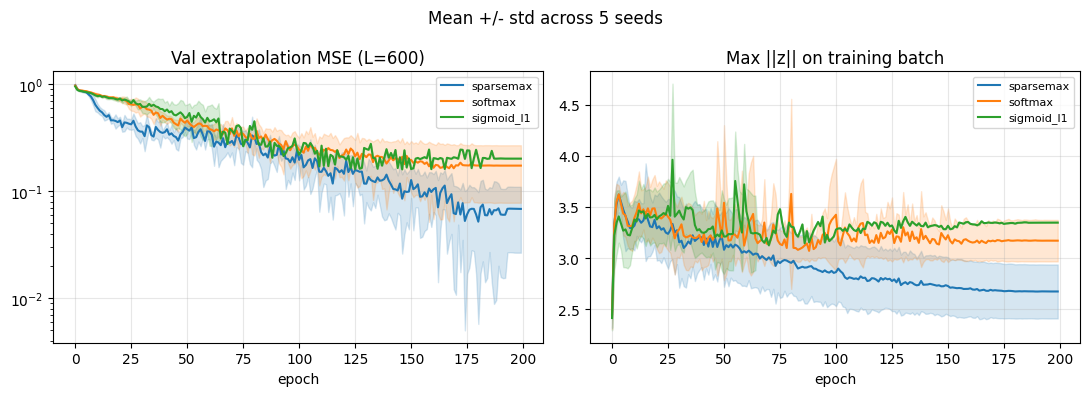

Per-form summary across seeds:
  sparsemax : diverged 0/5   best-val MSE  median 2.487e-02  mean 4.263e-02  std 4.618e-02
  softmax   : diverged 1/5   best-val MSE  median 1.652e-01  mean 2.437e-01  std 1.939e-01
  sigmoid_l1: diverged 4/5   best-val MSE  median 5.297e-01  mean 4.239e-01  std 1.765e-01


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in MODEL_NAMES:
    c = MODEL_COLOR[name]
    band(axes[0], stack_key(name, 'val_extrap'), c, name, logy=True)
    band(axes[1], stack_key(name, 'zmax'),       c, name, logy=False)
axes[0].set_title(f'Val extrapolation MSE (L={L_eval})')
axes[1].set_title('Max ||z|| on training batch')
for ax in axes:
    ax.set_xlabel('epoch'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
fig.suptitle(f'Mean +/- std across {len(SEEDS)} seeds')
plt.tight_layout(); plt.show()

print('Per-form summary across seeds:')
for name in MODEL_NAMES:
    nd = sum(h['diverged_at'] is not None for h in histories[name])
    bv = np.array([h['best_val'] for h in histories[name]], dtype=float)
    print(f'  {name:10s}: diverged {nd}/{len(SEEDS)}   best-val MSE  '
          f'median {np.nanmedian(bv):.3e}  mean {np.nanmean(bv):.3e}  std {np.nanstd(bv):.3e}')


/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_27814/93266641.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=MODEL_NAMES, showfliers=False, widths=0.5)


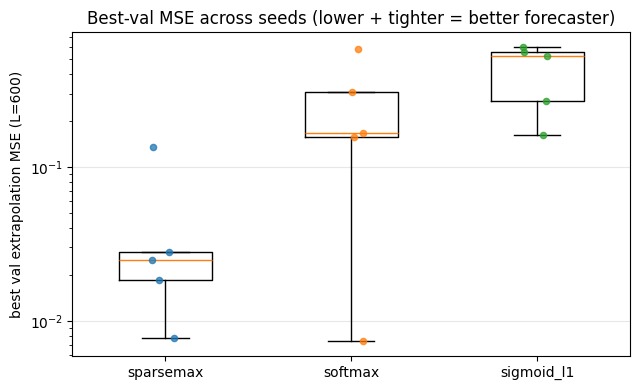

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4))
data = [np.array([h['best_val'] for h in histories[name]], dtype=float) for name in MODEL_NAMES]
ax.boxplot(data, labels=MODEL_NAMES, showfliers=False, widths=0.5)
rng = np.random.default_rng(0)
for i, (name, d) in enumerate(zip(MODEL_NAMES, data), start=1):
    d = d[np.isfinite(d)]
    x = i + (rng.random(len(d)) - 0.5) * 0.15
    ax.scatter(x, d, s=20, color=MODEL_COLOR[name], alpha=0.75, zorder=3)
ax.set_yscale('log')
ax.set_ylabel(f'best val extrapolation MSE (L={L_eval})')
ax.set_title('Best-val MSE across seeds (lower + tighter = better forecaster)')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### 5.2 Anchor sparsity — which anchors survive?

The whole point of the restrained $g$ is that redundant anchors switch **off**. We measure
per-anchor mean activation $\overline{|\alpha_i|}$ over the validation rollouts, count the
effective (active) anchors, and report the Hoyer sparsity of the mean-$\alpha$ vector across
the 5 seeds — then decode the learned anchors $\psi(g_i)$ against the true Duffing branches.
`sparsemax` should give exact zeros, `softmax` only soft shrinkage, `sigmoid_l1` gating toward 0.


In [13]:
ROLL = {}
for name in MODEL_NAMES:
    yh = np.full((len(SEEDS), Wva_d.shape[0], L_eval + 1), np.nan, dtype=np.float32)
    zz = torch.full((len(SEEDS), Wva_d.shape[0], L_eval + 1, M_LAT), float('nan'))
    for si in range(len(SEEDS)):
        with torch.no_grad():
            yhat, zs = rollout_y(models[name][si], Wva_d, Uva_d, L_eval, h_dt)
        yh[si] = yhat.cpu().numpy()
        zz[si] = zs.cpu()
    yh = np.where(np.isfinite(yh), yh, np.nan)
    ROLL[name] = {'yhat': yh, 'z': zz}

Yva_np  = Yva.numpy()
tline_e = np.arange(L_eval + 1) * h_dt
T_train = L * h_dt
print('precomputed val rollouts for', list(ROLL.keys()))

precomputed val rollouts for ['sparsemax', 'softmax', 'sigmoid_l1']


In [14]:
FT_NAMES = MODEL_NAMES
dyn0 = models[FT_NAMES[0]][0].dynamics
sigma_min = float(dyn0.sigma_min); R_g = float(dyn0.R_g)

# True Duffing equilibrium manifold over the training u-range: roots of q^3 - q - u = 0.
u_grid = np.linspace(-u_range, u_range, 200)
eqs_per_u = [equilibria(u) for u in u_grid]
assert min(len(e) for e in eqs_per_u) == max(len(e) for e in eqs_per_u) == 3
branches = np.array([[e[0] for e in eqs] for eqs in eqs_per_u])   # (200, 3): sinks/saddle

@torch.no_grad()
def eigvals_A(dyn, Z, chunk=2048):
    if Z.shape[0] == 0:
        return np.zeros((0, M_LAT), dtype=complex)
    out = []
    for i in range(0, Z.shape[0], chunk):
        out.append(torch.linalg.eigvals(dyn.A(Z[i:i+chunk])).cpu())
    return torch.cat(out, 0).numpy()

@torch.no_grad()
def g_image(dyn, Z, U):
    return dyn.g(Z, U)

def roll_latents(name, si):
    """Finite rollout latents for (name, seed index) plus their matched controls, on device."""
    Zfull = ROLL[name]['z'][si]                    # (B, T, m)
    B, T = Zfull.shape[0], Zfull.shape[1]
    Z = Zfull.reshape(-1, M_LAT)
    U = Uva_d.detach().cpu().view(-1, 1).expand(B, T).reshape(-1)
    mask = torch.isfinite(Z).all(dim=1)
    return Z[mask].to(device), U[mask].to(device)

print(f'sigma_min = {sigma_min}, R_g = {R_g};  forms = {FT_NAMES}')


sigma_min = 0.1, R_g = 2.0;  forms = ['sparsemax', 'softmax', 'sigmoid_l1']


In [15]:
@torch.no_grad()
def anchor_activation(dyn, Z, U, chunk=4096):
    """Mean |alpha_i| over samples -> (ell,)."""
    outs = []
    for i in range(0, Z.shape[0], chunk):
        a = dyn.coeffs(Z[i:i+chunk], U[i:i+chunk])
        outs.append(a.abs().cpu())
    return torch.cat(outs, 0).mean(0).numpy() if outs else np.zeros(dyn.ell)

def hoyer_sparsity(v):
    v = np.abs(np.asarray(v, dtype=float)); n = len(v)
    l1 = v.sum(); l2 = np.sqrt((v ** 2).sum()) + 1e-12
    return (np.sqrt(n) - l1 / l2) / (np.sqrt(n) - 1.0)

ELL_ = int(models[FT_NAMES[0]][0].dynamics.ell)
ACT_THRESH = 1e-2
ACT = {}   # name -> (n_seeds, ell) mean |alpha_i|
print(f'Anchor sparsity over validation rollouts (ell={ELL_}, active if mean|alpha_i| > {ACT_THRESH}):')
for name in FT_NAMES:
    arr = np.full((len(SEEDS), ELL_), np.nan)
    for si in range(len(SEEDS)):
        Zr, Ur = roll_latents(name, si)
        if Zr.shape[0] == 0:
            continue
        arr[si] = anchor_activation(models[name][si].dynamics, Zr, Ur)
    ACT[name] = arr
    n_active = (np.nan_to_num(arr) > ACT_THRESH).sum(1)
    hs = np.array([hoyer_sparsity(np.nan_to_num(a)) for a in arr])
    print(f'  {name:10s}: mean active anchors = {np.nanmean(n_active):.1f}/{ELL_}   '
          f'Hoyer sparsity = {np.nanmean(hs):.3f} +/- {np.nanstd(hs):.3f}')


Anchor sparsity over validation rollouts (ell=8, active if mean|alpha_i| > 0.01):
  sparsemax : mean active anchors = 5.6/8   Hoyer sparsity = 0.528 +/- 0.081
  softmax   : mean active anchors = 8.0/8   Hoyer sparsity = 0.300 +/- 0.106
  sigmoid_l1: mean active anchors = 8.0/8   Hoyer sparsity = 0.014 +/- 0.006


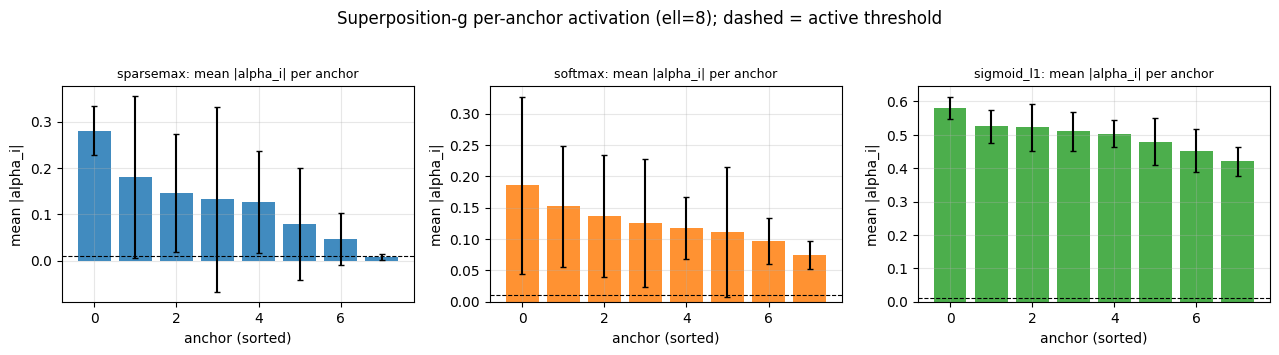

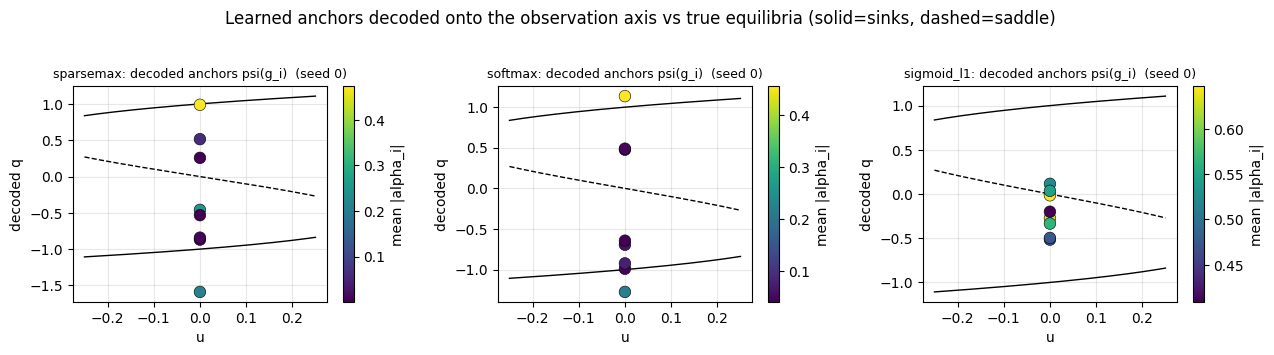

In [16]:
# Per-anchor mean activation (sorted), mean +/- std over seeds: vanishing bars = pruned anchors.
fig, axes = plt.subplots(1, len(FT_NAMES), figsize=(4.3 * len(FT_NAMES), 3.4), squeeze=False)
for j, name in enumerate(FT_NAMES):
    ax = axes[0][j]
    arr = ACT[name]
    mean = np.nanmean(arr, 0); std = np.nanstd(arr, 0)
    order = np.argsort(-mean)
    ax.bar(np.arange(ELL_), mean[order], yerr=std[order],
           color=MODEL_COLOR.get(name, 'C0'), alpha=0.85, capsize=2)
    ax.axhline(ACT_THRESH, color='k', ls='--', lw=0.8)
    ax.set_title(f'{name}: mean |alpha_i| per anchor', fontsize=9)
    ax.set_xlabel('anchor (sorted)'); ax.set_ylabel('mean |alpha_i|'); ax.grid(alpha=0.3)
fig.suptitle(f'Superposition-g per-anchor activation (ell={ELL_}); dashed = active threshold', y=1.03)
plt.tight_layout(); plt.show()

# Decoded anchors psi(g_i) vs true Duffing branches (seed 0), coloured by activation.
fig, axes = plt.subplots(1, len(FT_NAMES), figsize=(4.3 * len(FT_NAMES), 3.4), squeeze=False)
for j, name in enumerate(FT_NAMES):
    ax = axes[0][j]
    dyn = models[name][0].dynamics
    anch = dyn.g_mod.anchors().detach()                       # (ell, m)
    q_anch = models[name][0].decode(anch).detach().cpu().numpy().ravel()
    act0 = np.nan_to_num(ACT[name][0])
    ax.plot(u_grid, branches[:, 0], 'k-', lw=1.0)
    ax.plot(u_grid, branches[:, 2], 'k-', lw=1.0)
    ax.plot(u_grid, branches[:, 1], 'k--', lw=1.0)
    sc = ax.scatter(np.zeros_like(q_anch), q_anch, c=act0, cmap='viridis', s=70, zorder=3,
                    edgecolor='k', linewidth=0.4)
    plt.colorbar(sc, ax=ax, label='mean |alpha_i|')
    ax.set_title(f'{name}: decoded anchors psi(g_i)  (seed 0)', fontsize=9)
    ax.set_xlabel('u'); ax.set_ylabel('decoded q'); ax.grid(alpha=0.3)
fig.suptitle('Learned anchors decoded onto the observation axis vs true equilibria '
             '(solid=sinks, dashed=saddle)', y=1.03)
plt.tight_layout(); plt.show()


### 5.3 Structural sanity (contraction + $g$-bound)

In [17]:
print('Structural sanity on validation rollouts (both hold by construction):')
print(f'  contraction target: max Re lambda(A) <= -sigma_min = {-sigma_min:+.3f}')
print(f'  g-bound target:     max |g|_inf <= R_g = {R_g:.2f}')
for name in FT_NAMES:
    maxre = []; gmax = []
    for si in range(len(SEEDS)):
        Zr, Ur = roll_latents(name, si)
        if Zr.shape[0] == 0:
            continue
        ev = eigvals_A(models[name][si].dynamics, Zr)
        maxre.append(ev.real.max())
        gmax.append(g_image(models[name][si].dynamics, Zr, Ur).abs().max().item())
    maxre = np.array(maxre); gmax = np.array(gmax)
    ok_c = bool((maxre <= -sigma_min + 1e-4).all()); ok_g = bool((gmax <= R_g + 1e-4).all())
    print(f'  {name:10s}: max Re(lambda) = {maxre.max():+.4f} (ok={ok_c})    '
          f'max |g|_inf = {gmax.max():.3f} (ok={ok_g})')


Structural sanity on validation rollouts (both hold by construction):
  contraction target: max Re lambda(A) <= -sigma_min = -0.100
  g-bound target:     max |g|_inf <= R_g = 2.00
  sparsemax : max Re(lambda) = -0.1067 (ok=True)    max |g|_inf = 1.112 (ok=True)
  softmax   : max Re(lambda) = -0.1001 (ok=True)    max |g|_inf = 1.068 (ok=True)
  sigmoid_l1: max Re(lambda) = -0.1001 (ok=True)    max |g|_inf = 1.479 (ok=True)


### 5.4 Hidden-coordinate recoverability

Fit a *linear* map from the latent state to $q$ and to the hidden $\dot q$ on a held-out
split; the $R^2$ distribution across seeds probes how much of the true state each form's
latent encodes.

In [18]:
def linear_recovery_r2(Z, target):
    Z = np.asarray(Z); t = np.asarray(target)
    Zb = np.concatenate([Z, np.ones((Z.shape[0], 1))], axis=1)
    w, *_ = np.linalg.lstsq(Zb, t, rcond=None)
    pred = Zb @ w
    ss_res = np.sum((t - pred) ** 2)
    ss_tot = np.sum((t - t.mean()) ** 2) + 1e-12
    return 1.0 - ss_res / ss_tot, w

Q    = Xva[..., 0].numpy().reshape(-1)
Qdot = Xva[..., 1].numpy().reshape(-1)
N = Q.shape[0]
perm = np.random.default_rng(7).permutation(N)
fit_idx, eval_idx = perm[:N // 2], perm[N // 2:]

def r2_eval(Z, target):
    _, w = linear_recovery_r2(Z[fit_idx], target[fit_idx])
    pe = np.concatenate([Z[eval_idx], np.ones((len(eval_idx), 1))], 1) @ w
    ss_res = np.sum((target[eval_idx] - pe) ** 2)
    ss_tot = np.sum((target[eval_idx] - target[eval_idx].mean()) ** 2) + 1e-12
    return 1.0 - ss_res / ss_tot

R2 = {name: {'q': [], 'qdot': []} for name in MODEL_NAMES}
for name in MODEL_NAMES:
    for si in range(len(SEEDS)):
        Z = ROLL[name]['z'][si].reshape(-1, M_LAT).numpy()
        if not np.all(np.isfinite(Z)):
            R2[name]['q'].append(np.nan); R2[name]['qdot'].append(np.nan); continue
        R2[name]['q'].append(r2_eval(Z, Q))
        R2[name]['qdot'].append(r2_eval(Z, Qdot))

print('Linear recoverability (mean +/- std across seeds):')
for name in MODEL_NAMES:
    q = np.array(R2[name]['q']); qd = np.array(R2[name]['qdot'])
    print(f'  {name:9s}  R2->q  {np.nanmean(q):.3f} +/- {np.nanstd(q):.3f}    '
          f'R2->q_dot  {np.nanmean(qd):.3f} +/- {np.nanstd(qd):.3f}')

Linear recoverability (mean +/- std across seeds):
  sparsemax  R2->q  0.958 +/- 0.046    R2->q_dot  0.496 +/- 0.222
  softmax    R2->q  0.770 +/- 0.181    R2->q_dot  0.374 +/- 0.272
  sigmoid_l1  R2->q  0.622 +/- 0.161    R2->q_dot  0.096 +/- 0.083


/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_27814/2793687009.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_fin, labels=MODEL_NAMES, showfliers=False, widths=0.5)
/var/folders/9x/8bf0hckd1b122g3zlj_z9c1w0000gp/T/ipykernel_27814/2793687009.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_fin, labels=MODEL_NAMES, showfliers=False, widths=0.5)


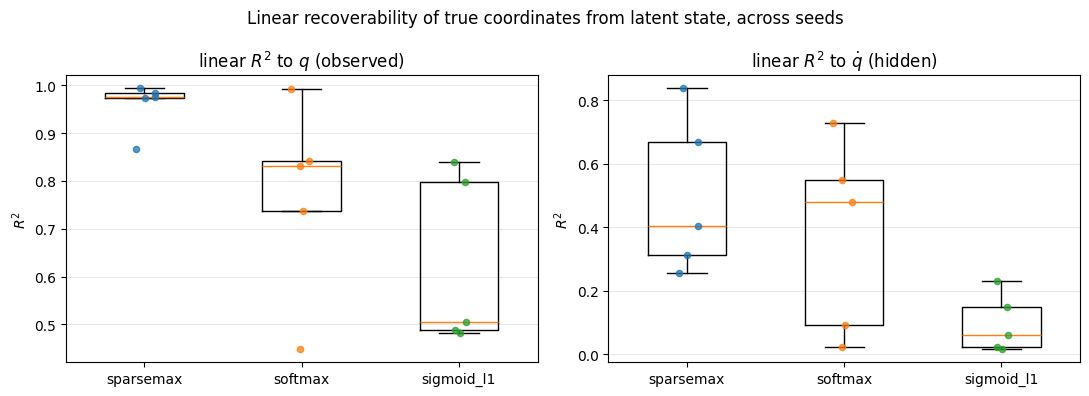

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, key, ttl in [(axes[0], 'q',    r'linear $R^2$ to $q$ (observed)'),
                     (axes[1], 'qdot', r'linear $R^2$ to $\dot q$ (hidden)')]:
    data = [np.array(R2[name][key], dtype=float) for name in MODEL_NAMES]
    data_fin = [d[np.isfinite(d)] for d in data]
    ax.boxplot(data_fin, labels=MODEL_NAMES, showfliers=False, widths=0.5)
    rng = np.random.default_rng(1)
    for i, (name, d) in enumerate(zip(MODEL_NAMES, data_fin), start=1):
        x = i + (rng.random(len(d)) - 0.5) * 0.15
        ax.scatter(x, d, s=20, color=MODEL_COLOR[name], alpha=0.75, zorder=3)
    ax.set_title(ttl); ax.set_ylabel(r'$R^2$'); ax.grid(alpha=0.3, axis='y')
fig.suptitle('Linear recoverability of true coordinates from latent state, across seeds')
plt.tight_layout(); plt.show()

## 6. Verdict — choosing a coefficient form

Pick the `alpha_form` for the full L-N / L-FT / L-FT+res study by weighing:

- **Accuracy (§5.1):** lowest and tightest best-val extrapolation MSE across seeds.
- **Sparsity (§5.2):** does it prune the over-specified basis? Prefer high Hoyer / few active
  anchors — `sparsemax` yields exact zeros, `softmax` only soft, `sigmoid_l1` gates toward 0
  under the L1 penalty.
- **Structure (§5.3):** contraction and $g$-bound must hold (guaranteed by construction, so this
  is a sanity check, not a discriminator).
- **Latent quality (§5.4):** higher $R^2$ to $q$ / $\dot q$ means the latent encodes more of the
  true (partially observed) state.

Then set `ALPHA_FORM` in the full notebook's config cell to the winner and run the 10-seed study.
